# Testing the effect of Balmer Absorption to the emission line ratios ([OIII]/H$\beta$)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from uncertainties import unumpy as unp
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *

#PATH = '/home/benjamin/Documents/analogs/specs/pypeit/'
os.chdir(magePath)
os.getcwd()

'/home/benjamin/Documents/analogs'

In [2]:
# Read absorptions and fluxes
balmer_abs = pd.read_csv('./results/balmer_absorption/balmer_abs.csv')
em_line_fluxes = pd.read_csv('./results/em_lines.csv')

In [3]:
oiii = []
oiii_err = []
hb = []
hb_err = []

hb_abs = []

for galaxy_name in em_line_fluxes['galname']:
    
    mask_em = (np.array(em_line_fluxes['galname']) == galaxy_name)
    mask_abs = (np.array(balmer_abs['Galaxy']) == galaxy_name)
    
    oiii.append(np.array(em_line_fluxes['[OIII]5007'])[mask_em][0])
    oiii_err.append(np.array(em_line_fluxes['[OIII]5007_err'])[mask_em][0])
    hb.append(np.array(em_line_fluxes['Hb'])[mask_em][0])
    hb_err.append(np.array(em_line_fluxes['Hb_err'])[mask_em][0])
    
    hb_abs.append(np.array(balmer_abs['Hb_abs'])[mask_abs][0])

In [4]:
OIII = unp.uarray(oiii, oiii_err)
HB = unp.uarray(hb, hb_err)
HB_abs = np.array(hb_abs)

In [6]:
ratio = OIII / HB
ratio_abs = OIII / (HB - HB_abs)

In [ ]:
(1 - ((hb - np.abs(hb_abs_flux)*1e-17)/hb))*100

In [26]:
err_perc = unp.std_devs(HB) / unp.nominal_values(HB) * 100

In [27]:
change_perc = (1 - ((unp.nominal_values(HB) - HB_abs) / unp.nominal_values(HB)))*100

In [28]:
change_perc < err_perc

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False])

In [29]:
HB_abs

array([3.98209482e-15, 3.65707696e-15, 5.71587185e-16, 4.76524296e-16,
       8.34974326e-16, 7.77250865e-16, 9.88381293e-16, 4.84262601e-16,
       7.08260225e-16, 1.43337271e-16, 4.74349631e-15, 4.57258702e-15,
       1.36253311e-15, 2.67967934e-15, 3.38831717e-16, 8.15302142e-16,
       1.18933144e-15, 6.08083245e-16])

In [30]:
HB

array([3.7131842215572416e-14+/-1.0421748771007555e-16,
       8.607194635338084e-15+/-2.8329865089424855e-17,
       7.661970769599613e-15+/-5.981089652717693e-17,
       2.3575381624228702e-14+/-1.0165261471213375e-16,
       8.66041621549535e-15+/-7.672015854081141e-17,
       6.0845109445502804e-15+/-6.348173495423647e-17,
       2.672751434367969e-15+/-1.0711475916318413e-17,
       6.632340053689417e-16+/-4.4747307966248085e-18,
       1.5126165007321633e-14+/-3.7798606859853714e-17,
       8.057028140726458e-15+/-4.593999962636606e-17,
       8.662612388663065e-14+/-1.6550627341585036e-16,
       1.6154738757901912e-15+/-1.6512702057463173e-17,
       5.694920749041524e-15+/-3.2315980756427305e-17,
       5.1980871423890256e-15+/-3.324609734701065e-17,
       2.122035655181448e-15+/-2.188963084460629e-17,
       1.6747537803319301e-15+/-5.48748902126088e-18,
       2.7592173217123346e-15+/-1.0617102733652392e-17,
       1.2578923887338583e-14+/-5.376619700341926e-17], dtype=obje

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'J0021'),
  Text(1, 0, 'J0023'),
  Text(2, 0, 'J0136'),
  Text(3, 0, 'J0240'),
  Text(4, 0, 'J0252'),
  Text(5, 0, 'J0305'),
  Text(6, 0, 'J0950'),
  Text(7, 0, 'J1146'),
  Text(8, 0, 'J1226'),
  Text(9, 0, 'J1444'),
  Text(10, 0, 'J1448'),
  Text(11, 0, 'J1624'),
  Text(12, 0, 'J2101'),
  Text(13, 0, 'J2119'),
  Text(14, 0, 'J2212'),
  Text(15, 0, 'J2215'),
  Text(16, 0, 'J2225'),
  Text(17, 0, 'J2337')])

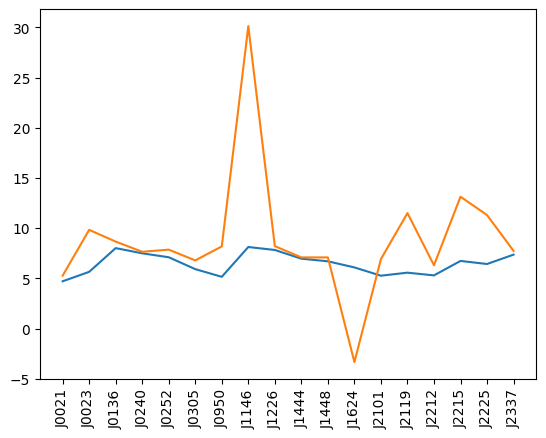

In [35]:
plt.plot(em_line_fluxes['galname'], unp.nominal_values(ratio))
plt.plot(em_line_fluxes['galname'], unp.nominal_values(ratio_abs))
plt.xticks(rotation=90)